In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

from xgboost import XGBClassifier

In [2]:
#Đọc dữ liệu
data = pd.read_csv(r"C:\Users\anhki\OneDrive\Desktop\creditcard (1).csv")
data.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
print(data.head())
print(data["Class"].value_counts())

   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

In [4]:
# Tách dữ liệu độc lập (X) và phụ thuộc (y)
X = data.drop("Class", axis=1)  # X chứa tất cả các cột trừ "Class"
y = data["Class"]               # y là cột đích cần dự đoán (0 hoặc 1)

In [5]:
# Chia tập Train/Test
# test_size=0.2: 20% dữ liệu để test, random_state giúp tái lặp kết quả
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Kích thước tập train:", X_train.shape)
print("Kích thước tập test:", X_test.shape)

Kích thước tập train: (227845, 30)
Kích thước tập test: (56962, 30)


In [6]:
# Chuẩn hóa dữ liệu
# StandardScaler đưa các đặc trưng về cùng thang đo (mean=0, std=1)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [12]:
# Khởi tạo và huấn luyện mô hình XGBoost
# scale_pos_weight giúp cân bằng giữa lớp 0 và lớp 1
# = (số mẫu lớp 0 / số mẫu lớp 1)
neg, pos = np.bincount(y_train)
scale_pos_weight = neg / pos
print("Tỉ lệ scale_pos_weight:", scale_pos_weight)

model = XGBClassifier(
    n_estimators=300,          # số lượng cây (boosting rounds)
    learning_rate=0.05,        # tốc độ học (nhỏ hơn giúp mô hình ổn định hơn)
    max_depth=5,               # độ sâu tối đa của mỗi cây
    subsample=0.8,             # lấy ngẫu nhiên 80% mẫu mỗi vòng
    colsample_bytree=0.8,      # lấy ngẫu nhiên 80% đặc trưng cho mỗi cây
    random_state=42,
    scale_pos_weight=scale_pos_weight,  # cân bằng giữa lớp 0 và 1
    eval_metric="logloss",     # hàm đánh giá (log loss phù hợp phân loại nhị phân)
    n_jobs=-1                  # dùng toàn bộ CPU để huấn luyện nhanh hơn
)

Tỉ lệ scale_pos_weight: 577.2868020304569


In [13]:
# Dự đoán xác suất
# predict_proba[:, 1] lấy xác suất thuộc lớp 1 (Fraud)
model.fit(X_train_scaled, y_train)
y_score = model.predict_proba(X_test_scaled)[:, 1]

In [14]:
# Chỉnh ngưỡng dự đoán để tối ưu precision hoặc recall
threshold = 0.8  
y_pred = (y_score >= threshold).astype(int)


=== Báo cáo phân loại ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.87      0.83      0.85        98

    accuracy                           1.00     56962
   macro avg       0.94      0.91      0.92     56962
weighted avg       1.00      1.00      1.00     56962



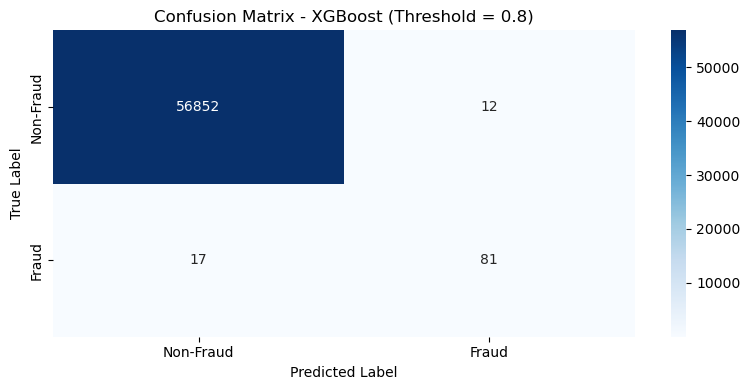


ROC AUC Score: 0.9131597912096746


In [15]:
# Đánh giá mô hình
print("\n=== Báo cáo phân loại ===")
print(classification_report(y_test, y_pred, digits=2))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
labels = ["Non-Fraud", "Fraud"]

plt.figure(figsize=(8, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels)
plt.title("Confusion Matrix - XGBoost (Threshold = 0.8)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

# ROC AUC
roc = roc_auc_score(y_test, y_pred)
print("\nROC AUC Score:", roc)

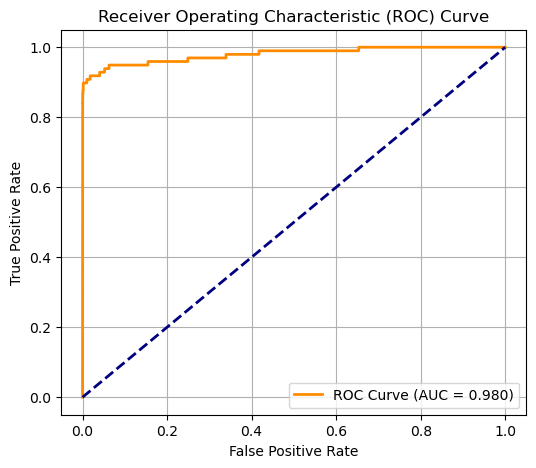

In [16]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Lấy xác suất dự đoán cho lớp 1 (fraud)
y_score = model.predict_proba(X_test_scaled)[:, 1]

# Tính FPR, TPR và AUC
fpr, tpr, thresholds = roc_curve(y_test, y_score)
roc_auc = auc(fpr, tpr)

# Vẽ biểu đồ
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


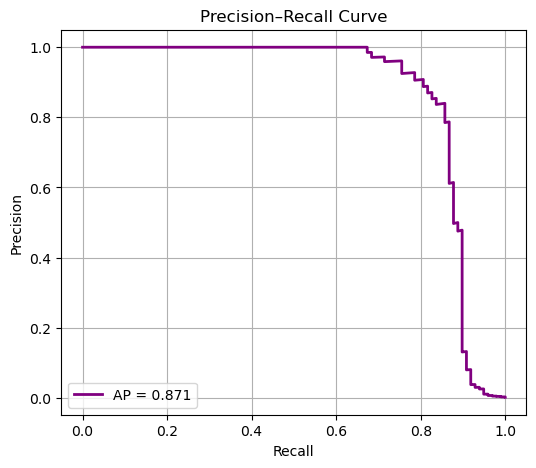

In [17]:
from sklearn.metrics import precision_recall_curve, average_precision_score

# Tính precision, recall
precision, recall, thresholds = precision_recall_curve(y_test, y_score)
avg_precision = average_precision_score(y_test, y_score)

# Vẽ biểu đồ
plt.figure(figsize=(6, 5))
plt.plot(recall, precision, color='purple', lw=2, label=f'AP = {avg_precision:.3f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision–Recall Curve')
plt.legend(loc="lower left")
plt.grid(True)
plt.show()
